# 02 · Temporal forecast evaluation

**Question:** can financial signals improve on simple GDP-growth baselines?

This notebook is an executable **synthetic demonstration**. No score below should be interpreted as observed forecasting skill in the US economy.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "macro.py").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt
from macro import synthetic_levels, transform, evaluate
plt.rcParams.update({"figure.figsize": (10, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
levels = synthetic_levels()
print("SYNTHETIC DEMONSTRATION — not observed US economic data")

SYNTHETIC DEMONSTRATION — not observed US economic data


## Define information and targets

At origin t, predictors use t−1 and t−2. Targets are GDP qoq growth at t+1 or t+4. The four-quarter horizon is not cumulative annual growth. Training targets must precede 2020Q1; test origins start in 2020Q1. Revised historical inputs would still prevent a real-time backtest claim.

In [2]:
scores, predictions, metadata = evaluate(levels, horizon=1)
metadata

{'horizon_quarters': 1,
 'train_rows': 156,
 'test_rows': 19,
 'train_last_target': '2019Q4',
 'test_first_origin': '2020Q1',
 'test_first_target': '2020Q2',
 'test_last_target': '2024Q4',
 'ridge_alpha': 100.0}

## Compare against baselines

Ridge tuning uses expanding temporal folds, an explicit label gap and scaling fitted inside the pipeline. Random forest uses fixed settings. The training mean and last observed GDP growth provide simple reference forecasts. Models are fitted once, before holdout evaluation.

In [3]:
scores.round(3)

,RMSE,MAE
model,,
Last observed growth,0.779,0.562
Training mean,0.539,0.423
Ridge,0.509,0.414
Random forest,0.531,0.441


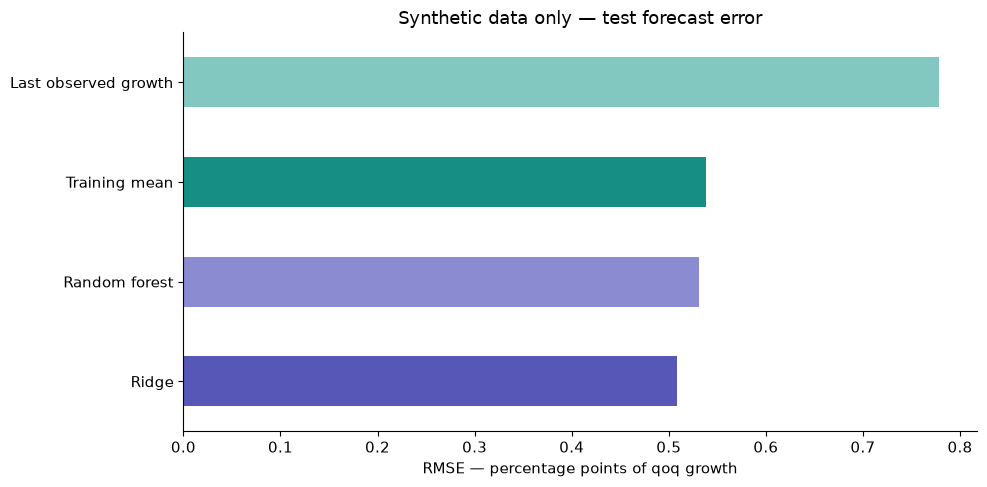

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
scores.sort_values("RMSE")["RMSE"].plot.barh(ax=ax, color=["#5657b7", "#8a8bd0", "#168e83", "#83c7c1"])
ax.set_xlabel("RMSE — percentage points of qoq growth")
ax.set_ylabel("")
ax.set_title("Synthetic data only — test forecast error")
fig.tight_layout()
plt.show()

## Four-quarter target

A larger horizon needs a larger label gap. Split metadata exposes the evaluated dates rather than assuming that all post-2020 targets are present.

In [5]:
scores_h4, _, metadata_h4 = evaluate(levels, horizon=4)
print(metadata_h4)
scores_h4.round(3)

{'horizon_quarters': 4, 'train_rows': 153, 'test_rows': 16, 'train_last_target': '2019Q4', 'test_first_origin': '2020Q1', 'test_first_target': '2021Q1', 'test_last_target': '2024Q4', 'ridge_alpha': 100.0}


,RMSE,MAE
model,,
Last observed growth,0.688,0.609
Training mean,0.458,0.364
Ridge,0.434,0.343
Random forest,0.443,0.364


## What this establishes

The pipeline can reproduce transformations, temporal separation and benchmark scores. Synthetic results establish execution, not economic validity. The original project explored additional models and VAR analysis; those are outside this compact public edition. Future research needs release-aware inputs and a genuinely new holdout before making stronger performance claims.